# LLM-Guided BO for BWR Enrichment Layouts: LLM Seeding + LLM Bounds Orchestration


**Status: experimental** — this notebook builds on the standard Bayesian Optimisation workflow from [`BO_Optimisation_BWR_NxN.ipynb`](https://github.com/light0vij/OpenMC-PRISM/blob/main/Notebooks/BO_Optimisation_BWR_NxN.ipynb) in the OpenMC-PRISM project. That notebook is still the main reference for the BO implementation, including the GP surrogate, Expected Improvement, symmetry decoding, and physics-based heuristics. I am not re-deriving those parts here. The main difference in this notebook is **how and where the LLM is brought into the optimisation loop**, as described below.

The idea is loosely inspired by the *region-lifted preference* approach described in [LLM-Guided Bayesian Optimization (LGBO)](https://arxiv.org/html/2605.17976v1). In that work, the LLM is queried at each BO iteration and its output is incorporated into the Gaussian Process as a formal shift of the GP posterior mean. In this notebook, I am taking a different and much simpler approach. **This is a separate implementation and does not use LGBO's region-lifting method, code, or theoretical framework.** The main similarity is the idea of using an LLM throughout the optimisation rather than only using it once to generate the initial population.

Here, the LLM is used at two points in the workflow:

1. **LLM Generative Seeding** — replaces Latin Hypercube Sampling (LHS) for the initial GP training set. Instead of generating space-filling points without any physics-based preference, the LLM is asked to generate candidate enrichment layouts based on different reactor-physics ideas and spatial distribution strategies.

2. **LLM Bounds Orchestration** — at each BO iteration, a second LLM call looks at the latest OpenMC result together with the current GP uncertainty and recommends how the numerical search bounds should be adjusted for the next iteration. The LLM does **not** choose the next design itself. Expected Improvement still selects the actual candidate; the LLM only changes the region of the design space that EI is allowed to search.

---

## Prompt files used in this notebook


**Sampling prompts** (LLM Generative Seeding, `sampler_prompts/*.json`) — three different sampling strategies were defined. Two of them, `Sampler_2` and `Sampler_3`, were run end-to-end and are used in the Results section below.

- **`disperse_llmsampler.json`** *(not included in the saved results below)* — asks the LLM to act as a senior nuclear engineer and favour a "dispersed islands" strategy. The idea is to keep high-enrichment rods in small, separated groups to provide some local self-shielding while avoiding the centre of the assembly to help keep power peaking under control.

- **`E_repulsion_llmsampler.json`** *(`Sampler_2` in the Results section)* — asks the LLM to maximise spatial dispersion using an "electrostatic repulsion" idea. The high-enrichment rods should be spread out as much as possible, while avoiding obvious geometric patterns such as strict checkerboards, rings, or bands. In this prompt, dispersion is given higher priority than PPF.

- **`hybrid_E_disperse_llmsampler.json`** *(`Sampler_3` in the Results section)* — uses the same repulsive-dispersion idea as `Sampler_2`, but adds one extra constraint: high-enrichment rods should never be placed at the exact geometric centre of the assembly.

All three sampling prompts ask the LLM to assign a *relative desirability score* between `[0, 1]` to each unique symmetric position rather than directly deciding whether a rod should be high or low enrichment. The existing `RunConfig.decode()` function is unchanged from the reference notebook. It ranks the scores and assigns exactly the required number of high-enrichment rods based on the fixed core inventory. This means that the actual score values are not important by themselves; what matters is their relative ordering.

**Orchestration prompt** (LLM Bounds Orchestration, `prompt2.json`) — uses the same general "prompt2" approach as the reference OpenMC-PRISM BO notebook. The LLM is asked to narrow and re-centre the search bounds towards regions where k∞ is more likely to be close to `k_target`. PPF is also considered, but as a secondary and softer objective rather than being treated as a strict cutoff.

---

## Workflow — where the LLM sits

The GP/EI/OpenMC mechanics similar to the one mentioned in the reference notebook linked above except with the LLM part. 

```
LLM-Guided Bayesian Optimisation — LLM touchpoints only
──────────────────────────────────────────────────────────────────────────

Phase A — LLM Generative Seeding  (replaces LHS)
  LLM proposes batches of desirability-score vectors (JSON)
        -> decode() to a binary layout -> Run OpenMC -> k∞, PPF, score
                        |
                        ▼
Phase B — Surrogate Fitting (GP)                 [unchanged — see reference notebook mentioned above]
  Train GP on all (layout, score) pairs collected so far
                        |
                        ▼
Phase C — Acquisition (EI)                       [unchanged — see reference notebook]
  Score 80,000 candidates cheaply via GP, pick highest Expected Improvement
                        |
                        ▼
Phase D — OpenMC Evaluation
  Decode selected candidate -> Run OpenMC -> append to dataset -> retrain GP
                        |
                        ▼
        ┌───────────────────────────────────┐
        │   LLM Bounds Orchestrator          │
        │   sees: k∞, PPF, GP uncertainty,   │
        │   adjacency count, current bounds  │
        │   -> recommends new search bounds  │
        └───────────────────┬─────────────────┘
                        |
                        ▼
        back to Phase C, with reshaped bounds, repeat for n_bo_iterations
```

## How the optimisation code talks to the LLM — from seeding to the BO loop


Both LLM components use the same basic request/response setup. The important part is what happens to the LLM-generated samples afterwards: they are decoded, evaluated in OpenMC, and then used directly as the initial training data for the GP before the BO loop starts.

1. **Ask** — A JSON configuration file from `sampler_prompts/*.json` provides the system prompt and the `command_template`. The system prompt contains the domain context, the "score, don't decide" instruction, and the particular dispersion strategy being tested. At runtime, the `command_template` is filled with the current geometry and optimisation information, including `n_vars`, the symmetric-position map, corner indices, `n_high_rods`, `k_target`, `ppf_target`, and the current batch number (for example, "3 of 6"). `LLMGridSampler` sends the completed prompt to the selected LLM provider and expects a raw JSON response containing distinct `{pattern, scores[...]}` objects. The response is expected to contain JSON only, without markdown fences or additional text.

2. **Decode** — The `scores` returned by the LLM are not an enrichment layout by themselves. Each score vector contains one value for every unique symmetric position and is passed through the existing `RunConfig.decode()` function. The scores are ranked, and exactly `n_high_rods` positions are assigned high enrichment while respecting the corner masking. The result is then mirrored according to the assembly symmetry to produce the complete N×N enrichment grid.

3. **Evaluate** — Each decoded grid is evaluated using OpenMC through `evaluate_fn`, in exactly the same way as a grid generated from LHS would be. The evaluation returns `k_inf`, `ppf`, `keff_std`, and the adjacency count. The composite score is then calculated using the existing `k_target`/`ppf_target` penalties and, when enabled, the adjacency penalty.

4. **GP Seeding** — This process continues batch by batch until the required `n_initial_samples` layouts have been generated by the LLM and evaluated in OpenMC. The resulting data, including `(X, keff, ppf, score, adj_high_rods, ...)`, is returned by `run_llmsampler()` as `llm_seed_data`. It uses the same dictionary structure as the output from `run_lhs()`, which is what allows the LLM sampler to replace LHS without changing the rest of the pipeline.

5. **BO** — `llm_seed_data` is then passed directly into `run_bo(..., llm_seed_data=llm_seed_data, ...)`. The first step in `run_bo()` is to train the GP surrogate using these LLM-generated and OpenMC-evaluated samples. This means the initial GP model is already based on the region of the design space favoured by the LLM's sampling strategy before Expected Improvement selects its first new candidate.

   From this point onwards, the main BO loop is the same as in the reference notebook: GP fitting, EI candidate selection, OpenMC evaluation, and GP retraining. The only additional step is that the LLM Bounds Orchestrator can adjust the EI search box after each new OpenMC result.

6. **Never crash, always log** — Both LLM components (`LLMGridSampler` and `LLMBoundsOrchestrator`) validate their responses against a strict schema. If a response is malformed or a required field is missing, the optimisation does not stop. The sampler falls back to safe random-uniform scores, while the bounds orchestrator falls back to a fixed-radius re-centering of the previous/default bounds. The fallback is recorded in the logs.

   The raw LLM responses are also saved verbatim to disk in `*_sampler_replies.txt` and `*_rawOrchestrator_replies.txt`. This makes it possible to inspect exactly what the model returned after a run. The LLM never directly modifies OpenMC, the GP, or Expected Improvement. It only provides inputs or suggestions that are then handled and validated by the existing deterministic optimisation pipeline.

---

## Results — `Sampler_2` (E-repulsion) vs `Sampler_3` (Hybrid E-repulsion + centre-exclusion) vs plain LHS baseline

Two of the three sampling strategies were tested end-to-end using the same 6×6 Gundremmingen-A-style BWR assembly. The assembly contained 23 high-enrichment rods out of 36, with corner masking and the adjacency penalty enabled. Both runs used the same `prompt2.json` orchestration setup, with 36 LLM-generated seed samples followed by 30 BO iterations.

The results were then validated using a higher-fidelity OpenMC run with 50,000 particles and compared against the original plain LHS-seeded BO baseline from the OpenMC-PRISM notebook, using the same optimisation settings.

| Optimisation method                               | Design (50,000-particle HiFi re-run) |      k∞ | σ(k∞) [pcm] |    PPF |
| ------------------------------------------------- | ------------------------------------ | ------: | ----------: | -----: |
| Plain LHS + BO *(OpenMC-PRISM baseline)*          | Optimal layout (HiFi re-run)         | 1.27174 |       29.79 | 1.1049 |
| `Sampler_2` — E-repulsion seeding                 | Optimal layout (HiFi re-run)         | 1.27212 |       29.62 | 1.0994 |
| `Sampler_3` — Hybrid repulsion + centre exclusion | Optimal layout (HiFi re-run)         | 1.27111 |       33.19 | 1.0986 |

*k∞ target = 1.25 and the PPF limit is ≤ 1.30. During BO, the low-fidelity evaluations used 5,000 particles. The final designs were re-evaluated using 50,000 particles. The HiFi results were statistically consistent with the corresponding BO-time estimates, with |Z| values of 1.34 for `Sampler_2` and 1.05 for `Sampler_3`, indicating that the final results are not simply low-fidelity Monte Carlo noise.*

At this assembly size and with the available iteration budget, all three approaches ended up finding very similar solutions. The difference in k∞ between them is only around a tenth of a percent, and the PPF values are also very close. `Sampler_2` gave the k∞ value closest to the target among the three approaches, while both LLM-seeded runs produced slightly lower PPF values than the plain LHS baseline.

However, the final optimum is not the most interesting part of the comparison. The bigger difference can be seen in the initial samples, before BO has had the chance to fine-tune the search.

Both `Sampler_2` and `Sampler_3` used the same orchestration prompt, the same 6×6 assembly with 23 high-enrichment rods, and the same physics settings. The only difference between the two runs was the sampling prompt given to the LLM.

Looking through the raw sampler responses (`*_sampler_replies.txt`) and the evaluation data (`*_all_evaluations.csv`) shows that both sampling strategies behaved broadly as intended. The first batch of LLM-generated designs already fell into a relatively narrow region of the search space, with k∞ values close to the target and PPF values comfortably below the 1.30 limit.

Across the 36 LLM seed samples, both `Sampler_2` and `Sampler_3` produced k∞ values roughly between 1.267 and 1.276, while the PPF values were approximately between 1.10 and 1.13. This means that, even before BO started, the LLM was already generating layouts with reasonably well-controlled power peaking. Compared with a completely uninformed LHS population, the initial LLM samples were concentrated in a much narrower and more useful region of the design space.

The additional centre-exclusion instruction in `Sampler_3` did change the way the LLM generated the layouts. Several of the raw responses explicitly avoided giving high scores to the central diagonal positions, and the reasoning frequently referred to suppressing or avoiding the central rods. However, this did not produce a noticeable improvement in the final solution for this particular 6×6 problem. Both sampling strategies eventually converged to almost the same region.

One interesting difference is where the best solution appeared during each run. For `Sampler_3`, the best score over the entire optimisation was already found during the initial LLM seed phase. The following 30 BO iterations were able to match that result but did not improve on it. In contrast, `Sampler_2` still saw a small improvement during the BO phase compared with its best initial LLM-generated design.

This suggests that the additional centre-avoidance constraint in `Sampler_3` may have pushed the initial LLM samples into a strong region of the design space straight away, leaving BO with less room for improvement. The pure E-repulsion strategy used in `Sampler_2` appears to have left a little more room for BO to fine-tune the solution.

In both cases, the main effect of the LLM seems to be reducing the amount of unproductive exploration needed at the start of the optimisation. Instead of beginning from a completely uninformed set of samples, BO starts with training data that is already concentrated in a physically reasonable region of the search space. At this relatively small assembly size, BO has enough iterations to compensate for differences between the initial sampling strategies, which is probably why the final results are so similar. The difference could become more important for larger assemblies or when the available optimisation budget is more limited.

The `main takeaway` from these runs is therefore more methodological than numerical. Comparing the different sampling prompts — `disperse`, `E_repulsion`, and `hybrid_E_disperse` — shows that the LLM can be guided towards different regions of the design space simply by changing the wording of the sampling instructions.

For example, instructions such as favouring dispersed islands, maximising electrostatic-style repulsion, or explicitly avoiding high-enrichment placement near the centre resulted in noticeably different placement strategies in the raw LLM responses. This can be seen in the returned `pattern` labels as well as the accompanying `reasoning` fields. The underlying decode, corner-masking, adjacency-penalty, OpenMC evaluation, and BO pipeline remained unchanged.

This makes the sampling prompt effectively a natural-language control over where the initial GP training data comes from. For the current 6×6 problem, the deterministic constraints and BO loop were strong enough that most of the differences in the initial populations disappeared by the end of the optimisation. However, the underlying approach is still useful: instead of manually coding every possible placement heuristic, the LLM can be asked to generate candidate regions or potentially promising layouts based on different physical ideas, while the actual optimisation and physics evaluation remain under the control of the existing BO and OpenMC workflow.

The complete run artefacts, including the raw LLM responses, per-sample evaluation CSV files, convergence plots, and design reports, are available in:

`Results/Sampler_2_BO-prompt2_BWR_6x6_LLM-BO/` and
`Results/Sampler_3_BO-prompt2_BWR_6x6_LLM-BO/`

---

***Note*:-:** for the `Sampler_2` (E-repulsion) run, the LLM used for both generative seeding and bounds orchestration was **`llama-3.3-70b-versatile`** via Groq (the `groq` provider entry in `E_repulsion_llmsampler.json` / `prompt2.json`). `llama-3.3-70b-versatile` models were decommissioned from groq, so for the `Sampler_3` (hybrid) run — and for all sampling/orchestration prompts going forward — **`sarvam-105b`** via Sarvam AI (the `sarvam` provider entry) was used instead for both the seeding and the orchestration calls.

---



# User Inputs
**(Change only `BWR_N` and `N_HIGH_RODS` to switch assembly size.)**

In [3]:
BWR_N        = 6    # –––––> Side length of the square assembly
N_HIGH_RODS  = 23   # –––––> Number of high-enrichment rods in the
                    #   full N×N grid (assembly-specific physics input)

import os
##****** Toggles: Both true ––> toggles turned on; Both False ––> turned off **********#####

ENABLE_CORNER_MASKING = True  #True or False         
ENABLE_ADJACENCY_PENALTY = True      #True or False  
ENABLE_ADJACENCY_PENALTY_WEIGHT = 3.0
ENABLE_LLM_ORCHESTRATOR = True   # True or False 



K_PENALTY = 50       
PPF_PENALTY  = 5   

################ LLM Key, provider and Prompt file #####################
API_KEY = os.environ.get("LLM_API_KEY", "")   # ------> set via: docker run -e LLM_API_KEY=... 
#API_KEY = "YOUR API KEY HERE"


LLM_PROVIDER = "sarvam"   # "grok" / "gemini" / "groq" / "anthropic"/ "saravam"

prompt_file = "prompt2" #JSON file name for the orchestration


sampler_1 = "disperse_llmsampler"
sampler_2 = "E_repulsion_llmsampler"
sampler_3 = "Hybrid_E_disperse_llmsampler"


sampler_prompt   = sampler_3  #json file name of the LLM sampler 

############## No: of LHS and BO runs################################ 
scale_factor = (BWR_N / 6) ** 2
base_llm = int(30 * scale_factor)     #30  
base_bo  = int(20 * scale_factor)    #20

use_physics_heuristics = ENABLE_CORNER_MASKING or ENABLE_ADJACENCY_PENALTY


INITIAL_SAMPLES_LHS = int(base_llm * 1.2) if use_physics_heuristics else base_lhs
BO_ITERATIONS       = int(base_bo  * 1.5) if use_physics_heuristics else base_bo


N_TOTAL = BWR_N ** 2
N_SYM   = BWR_N * (BWR_N + 1) // 2


sampler_prefix_map = {
    sampler_1: "Sampler_1",
    sampler_2: "Sampler_2",
    sampler_3: "Sampler_3"
}
prefix = sampler_prefix_map.get(sampler_prompt, "Unknown_Sampler")

MODEL_NAME  = f"{prefix}_BO-{prompt_file}_BWR_{BWR_N}x{BWR_N}_LLM-BO"
RESULTS_DIR = f"../Results/{MODEL_NAME}"
os.makedirs(RESULTS_DIR, exist_ok=True)

print(f"Setup complete: {MODEL_NAME}")


Setup complete: Sampler_3_BO-prompt2_BWR_6x6_LLM-BO


# Imports

In [4]:

import openmc
import sys, os
import warnings
from functools import partial
import matplotlib.pyplot as plt
import numpy as np
from sklearn.exceptions import ConvergenceWarning
import json
warnings.filterwarnings("ignore", category=ConvergenceWarning)

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from openmc_bo import (
    RunConfig,
    run_llmsampler,
    run_bo,
    run_smoke_test,
    LLMBoundsOrchestrator,
    summarise_results,
    plot_convergence,
)

from environments.env        import evaluate_for_bo, get_model_params
from environments.bwr_vis    import plot_enr_grid 
from environments.bwr_report import export_design_report

from environments.mapping    import ENR_LOW, ENR_HIGH



print("Imports successful.")

Imports successful.


# BO Configuration

In [5]:

cfg_bo = RunConfig(
    
    n_rods_side  = BWR_N,           # derived from Cell 1
    n_high_rods  = N_HIGH_RODS,     # derived from Cell 1

   
    
     # Physics-informed constraints
    k_target   = 1.25,
    ppf_target = 1.30,
    alpha_k    = K_PENALTY,      
    alpha_ppf  = PPF_PENALTY,    

   
        
    use_corner_masking    = ENABLE_CORNER_MASKING,    
    
    use_adjacency_penalty = ENABLE_ADJACENCY_PENALTY,         
    adj_penalty_weight    = ENABLE_ADJACENCY_PENALTY_WEIGHT, 
               
    
    # BO parameters
    n_initial_samples = INITIAL_SAMPLES_LHS,         
    n_bo_iterations   = BO_ITERATIONS,
    n_candidates      = 80000,
    ei_xi             = 0.01,
    gp_restarts       = 10,
    random_seed       = 42,

    # OpenMC particles
    n_particles = 5000,   #5000
    n_inactive  = 25,    #25
    n_active    = 50,    #50

    # OpenMC particles for smoke test
    n_particles_smoke = 500,   #500
    n_inactive_smoke  = 10,
    n_active_smoke    = 20,


    model_name  = MODEL_NAME,
    results_dir = RESULTS_DIR,
)

# Dependency
evaluate_fn = partial(evaluate_for_bo, cfg=cfg_bo)

print(cfg_bo.summary())

RunConfig — Sampler_3_BO-prompt2_BWR_6x6_LLM-BO
  Assembly           : 6×6 = 36 pins
  Design variables   : 21  
  ENR_LOW            : 1.87 wt%
  ENR_HIGH           : 2.53 wt%
  n_high_rods        : 23 / 36
  k-inf target       : 1.25  (alpha_k = 50)
  PPF target         : 1.3  (alpha_ppf = 5)
  LHS samples        : 36
  BO iterations      : 30
  Corner masking     : True
  Adjacency penalty  : True  (weight=3.0)
  OpenMC particles   : 5000  (25 inactive + 50 active)
  Smoke particles    : 500  (10 inactive + 20 active)
  Results dir        : ../Results/Sampler_3_BO-prompt2_BWR_6x6_LLM-BO


# Smoke Test

In [6]:

rng_smoke = np.random.default_rng(cfg_bo.random_seed)
smoke_x   = rng_smoke.uniform(0, 1, size=cfg_bo.n_vars)  # size auto-correct for NxN

smoke_res = run_smoke_test(cfg_bo, evaluate_fn, smoke_x)

print(f"k∞  = {smoke_res['keff']:.5f}")
print(f"PPF = {smoke_res.get('ppf', 'N/A')}")

print(f"Adjacent hi rods  : {smoke_res.get('adj_high_rods',    'N/A')}")

  SMOKE TEST — Sampler_3_BO-prompt2_BWR_6x6_LLM-BO
══════════════════════════════════════════════════════════════════════
  Continuous vector (first 6): [0.774 0.439 0.859 0.697 0.094 0.976]
  Decoded grid       : 23 × 2.53%  +  13 × 1.87%  (avg 2.2917 wt%)
  Particles          : 500  (10 inactive + 20 active)

  k∞    = 1.25399 ± 0.00968   (target = 1.25)
  |Δk∞| = 0.00399
  PPF   = 1.1803   (limit ≤ 1.3)   feasible
k∞  = 1.25399
PPF = 1.1802613385701508
Adjacent hi rods  : 22


# LLM seeding

In [7]:
sampler_file_path = f"../sampler_prompts/{sampler_prompt}.json"

with open(sampler_file_path, "r") as f:
    llm_sampler = json.load(f)

llm_raw_replies = f"{RESULTS_DIR}/{MODEL_NAME}_sampler_replies.txt"

print(f"Logs will be saved to: {llm_raw_replies}\n")
print(llm_sampler["llm_prompt"])


Logs will be saved to: ../Results/Sampler_3_BO-prompt2_BWR_6x6_LLM-BO/Sampler_3_BO-prompt2_BWR_6x6_LLM-BO_sampler_replies.txt

Act like a senior nuclear engineer specialised in Boiling Water Reactor (BWR) fuel assembly design and core physics optimisation. You are generating INITIAL SEED DESIGNS for a Bayesian Optimisation (BO) loop that searches a continuous design vector encoding a fuel-rod enrichment layout for a BWR assembly, replacing plain Latin Hypercube Sampling (LHS). The assembly is square with 1/2-diagonal symmetry, so only a unique subset of rod positions needs to be specified; the rest of the grid is mirrored automatically. Each unique position has an index and a (row, col) coordinate, and is flagged as diagonal or off-diagonal. Your job is NOT to output a binary high/low decision directly. Instead, for every unique position you output a continuous 'desirability score' in [0, 1] representing how strongly you want that position to end up HIGH enrichment relative to the othe

In [8]:

llm_seed_data = run_llmsampler(
    cfg=cfg_bo, 
    evaluate_fn=evaluate_fn, 
    api_key=API_KEY, 
    config_path= sampler_file_path, 
    provider=LLM_PROVIDER,
    raw_log_path=llm_raw_replies,
    verbose=True,
    timeout_s = 100.0
)

LLM sample batches:   0%|          | 0/6 [00:00<?, ?it/s]

  [batch 1/6] 6 samples  (LLM)  reasoning: This batch mixes quasi-regular shell rings, stochastic repulsion, and biased perimeter scatterings to enforce centre exclusion and maximise 23-rod dispersion without rigid symmetry.
  [batch 2/6] 6 samples  (LLM)  reasoning: This batch employs diverse repulsive dispersion strategies: perimeter clustering, corner-avoiding checkerboard-inspired scatter, diagonal-avoidance rings, and randomized electrostatic scattering, all enforcing a strict low-score centre while maximizing spatial separation and avoiding rigid geometric symmetry.
  [batch 3/6] 6 samples  (LLM)  reasoning: Batch 3 employs a mix of electrostatic repulsion, eccentric off-center ring fragments, and perimeter-biased scattering to ensure high-enrichment rods are maximally dispersed away from the forbidden geometric center and corner-forced low zones without rigid symmetry.
  [batch 4/6] 6 samples  (LLM)  reasoning: This batch mixes perimeter-biased repulsion with diagonal ring avoid

LLM samples:   0%|          | 0/36 [00:00<?, ?it/s]

  [ 1/36]  k∞=1.27087 ±0.00169  PPF=1.101  score=-67.04375
  [ 2/36]  k∞=1.27313 ±0.00197  PPF=1.103  score=-67.15625
  [ 3/36]  k∞=1.27279 ±0.00186  PPF=1.100  score=-73.13938
  [ 4/36]  k∞=1.27271 ±0.00163  PPF=1.103  score=-73.13536
  [ 5/36]  k∞=1.27591 ±0.00212  PPF=1.127  score=-67.29562
  [ 6/36]  k∞=1.26947 ±0.00179  PPF=1.103  score=-66.97364
  [ 7/36]  k∞=1.27317 ±0.00154  PPF=1.117  score=-67.15865
  [ 8/36]  k∞=1.27294 ±0.00151  PPF=1.113  score=-73.14702
  [ 9/36]  k∞=1.27011 ±0.00217  PPF=1.102  score=-73.00529
  [10/36]  k∞=1.26875 ±0.00221  PPF=1.105  score=-60.93765
  [11/36]  k∞=1.27050 ±0.00218  PPF=1.123  score=-67.02478
  [12/36]  k∞=1.26875 ±0.00221  PPF=1.105  score=-60.93765
  [13/36]  k∞=1.27297 ±0.00209  PPF=1.115  score=-79.14859
  [14/36]  k∞=1.27280 ±0.00188  PPF=1.106  score=-73.13975
  [15/36]  k∞=1.27353 ±0.00192  PPF=1.109  score=-73.17653
  [16/36]  k∞=1.26938 ±0.00208  PPF=1.109  score=-84.96907
  [17/36]  k∞=1.27280 ±0.00188  PPF=1.106  score=-73.139

# LLM Orchestration


In [9]:
# Load the external LLM command 

config_file_path = f"../{prompt_file}.json"

with open(config_file_path, "r") as f:
    llm_config = json.load(f)

raw_replies_path = f"{RESULTS_DIR}/{prompt_file}_rawOrchestrator_replies.txt"

print(f"Loaded {prompt_file}.json")
print(llm_config["llm_prompt"])


Loaded prompt2.json
Act like a senior nuclear engineer specialized in Boiling Water Reactor (BWR) fuel assembly design and core physics optimization. You should act like an orchestrator inside an automated Bayesian Optimization (BO) loop that searches a continuous design vector encoding a fuel-rod enrichment layout for a BWR assembly. Each iteration, an OpenMC Monte Carlo simulation evaluates one candidate layout and reports k-infinity (k_inf), the Power Peaking Factor (PPF), and the exact enrichment grid used. You will be shown the results of the most recently evaluated layout plus the Gaussian Process (GP) surrogate's current predictive uncertainty. Your only job is to recommend how to reshape the numerical search region (the lower/upper bounds of the continuous design vector) that the Bayesian Optimisation's acquisition function is allowed to sample from next. You don't choose the next design point yourself -- the mathematical function (Expected Improvement) still selects the exact 

In [10]:
if ENABLE_LLM_ORCHESTRATOR:
    llm_orchestrator = LLMBoundsOrchestrator(
        api_key     = API_KEY,
        cfg         = cfg_bo,
        config_path = config_file_path,
        provider    = LLM_PROVIDER,
        raw_log_path = raw_replies_path,
        timeout_s=60.0  # -------------------------------->  Give the API more time to think
    )
    print(f"LLM orchestrator active — provider={LLM_PROVIDER}")
else:
    llm_orchestrator = None   
    print("LLM disabled")


LLM orchestrator active — provider=sarvam


# BO

In [11]:

from datetime import datetime

output_path = f"{RESULTS_DIR}/{MODEL_NAME}_llmbo_runs_log.txt"


bo_data = run_bo(
    cfg=cfg_bo,
    evaluate_fn=evaluate_fn,
    llm_seed_data=llm_seed_data,  
    llm_orchestrator=llm_orchestrator,
    verbose=True,
)

def _json_default(o):
    if isinstance(o, np.ndarray):
        return o.tolist()
    if isinstance(o, (np.floating, np.integer)):
        return o.item()
    return str(o)

with open(output_path, "a") as f:

    
    f.write("\n" + "=" * 70 + "\n")
    f.write(f"RUN — {datetime.now().isoformat()}\n")
    f.write("\n" + "=" * 70 + "\n")
    f.write(f"LLM Model  : {bo_data.get('llm_model', 'N/A')}\n")
    f.write(f"Best score : {bo_data['score'].max()}\n")
    f.write(f"keff       : {bo_data['keff'].tolist()}\n")
    f.write(f"ppf        : {bo_data['ppf'].tolist()}\n")
    f.write("\nbo_log:\n")
    f.write(json.dumps(bo_data.get("bo_log", []), default=_json_default, indent=2))
    f.write("\n\nllm_log:\n")
    f.write(json.dumps(bo_data.get("llm_log", []), default=_json_default, indent=2))

    '''

       #####--- Consolidated BO & LLM Run Logging ---########
        
        - Saves the complete optimisation run to a master text file.
        - Includes the LLM model, best score, and all keff/PPF results.
        - Keeps two separate JSON logs:
        - bo_log: Stores the evaluated design vectors, OpenMC results, scores, and the search bounds used at each iteration.
        - llm_log: Stores the LLM's parsed reasoning, adjustment mode, fallback status, and the bounds recommended for the next iteration.

    '''


print(f"{MODEL_NAME} - logs in -> {output_path}")



GP surrogate — 36 training points
  Kernel : 1.01**2 * Matern(length_scale=[10, 10, 10, 0.757, 0.988, 10, 10, 10, 10, 1.31, 10, 10, 10, 0.232, 10, 10, 10, 0.403, 10, 10, 5.99], nu=2.5) + WhiteKernel(noise_level=9.86e-06)
  Log-marginal-likelihood : -47.5408

Running 30 BO iterations …
Objective : − 50·|1.25 − k∞| − 5·max(0, PPF − 1.3)²  − adj_weight·adj_high_rods
Adjacency penalty (score term)  : ENABLED  (weight=3.0)
LLM-guided bounds orchestration : ENABLED (provider=sarvam)
--> HYBRID mode: adjacency penalty + LLM prompt.



BO iterations:   0%|          | 0/30 [00:00<?, ?it/s]

  BO  1 [total=37]:  k∞=1.27615 ±0.00179  |Δk|=0.02615  PPF=1.094  adj=28(w=3.00)  score=-85.30750  best=-60.93765
      [LLM] bounds updated — The current k_inf is 1.276, 0.026 above the 1.25 target, so a strong negative bias toward lower enrichment is needed to pull k_inf down, while the moderate PPF of 1.09 leaves room to narrow the search.
  BO  2 [total=38]:  k∞=1.27036 ±0.00184  |Δk|=0.02036  PPF=1.105  adj=26(w=3.00)  score=-79.01777  best=-60.93765
      [LLM] bounds updated — k_inf is slightly above target at 1.270, so biasing the search toward lower enrichment (negative center_bias) to find a flatter k_inf gradient, while keeping the radius moderate because PPF remains well below the 1.3 limit and GP uncertainty is still high for further exploration.
  BO  3 [total=39]:  k∞=1.27160 ±0.00166  |Δk|=0.02160  PPF=1.106  adj=22(w=3.00)  score=-67.07979  best=-60.93765
      [LLM] bounds updated — k-infinity is slightly high relative to target; shifting the center upward by ~0.32 n

In [12]:
best         = summarise_results(cfg_bo, bo_data, save=True, verbose=True)
enr_grid_opt = cfg_bo.decode(best["x"])

══════════════════════════════════════════════════════════════════════
  OPTIMAL ENRICHMENT LAYOUT (BO) — Sampler_3_BO-prompt2_BWR_6x6_LLM-BO
══════════════════════════════════════════════════════════════════════
  Found at                           : BO (iter 12)
  High-enrichment rods (2.53%)  : 23 / 36
  Average enrichment                 : 2.2917 wt%

  k∞                                 : 1.26875 ± 0.00221
  k∞ target                          : 1.25
  |Δk∞|                              : 0.01875  (1875.3 pcm)
  PPF                                : 1.1050  (target ≤ 1.3)
  PPF constraint                     : SATISFIED  
  Composite score                    : -60.937654
  Total evaluations                  : 66
  Feasible designs found             : 66 / 66
══════════════════════════════════════════════════════════════════════
BO results saved –> ../Results/Sampler_3_BO-prompt2_BWR_6x6_LLM-BO/Sampler_3_BO-prompt2_BWR_6x6_LLM-BO_all_evaluations.csv


In [13]:
#To check the BO data dimensions 
print(f"Number of evaluations saved: {len(bo_data['keff'])}")
print(f"Number of variables per row: {bo_data['X'].shape[1]}")

Number of evaluations saved: 66
Number of variables per row: 21


# Optimal Design Plot

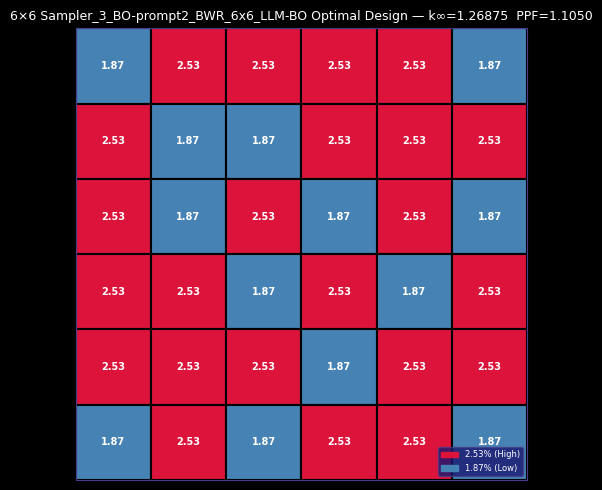

Grid saved → ../Results/Sampler_3_BO-prompt2_BWR_6x6_LLM-BO/Sampler_3_BO-prompt2_BWR_6x6_LLM-BO_optimal_grid.png


In [14]:

# Save optimal grid immediately
fig_grid, ax = plt.subplots(1, 1, figsize=(5, 5))
fig_grid.patch.set_facecolor("black")
plot_enr_grid(
    enr_grid_opt,
    title = f"{BWR_N}×{BWR_N} {MODEL_NAME} Optimal Design — k∞={best['keff']:.5f}  PPF={best['ppf']:.4f}",
    ax    = ax,
)
plt.tight_layout()
grid_path = f"{RESULTS_DIR}/{MODEL_NAME}_optimal_grid.png"
fig_grid.savefig(grid_path, dpi=150, bbox_inches="tight", facecolor="black")
plt.show()
print(f"Grid saved → {grid_path}")

# Convergence plot + text report

Convergence plot saved → ../Results/Sampler_3_BO-prompt2_BWR_6x6_LLM-BO/Sampler_3_BO-prompt2_BWR_6x6_LLM-BO_bo_convergence.png


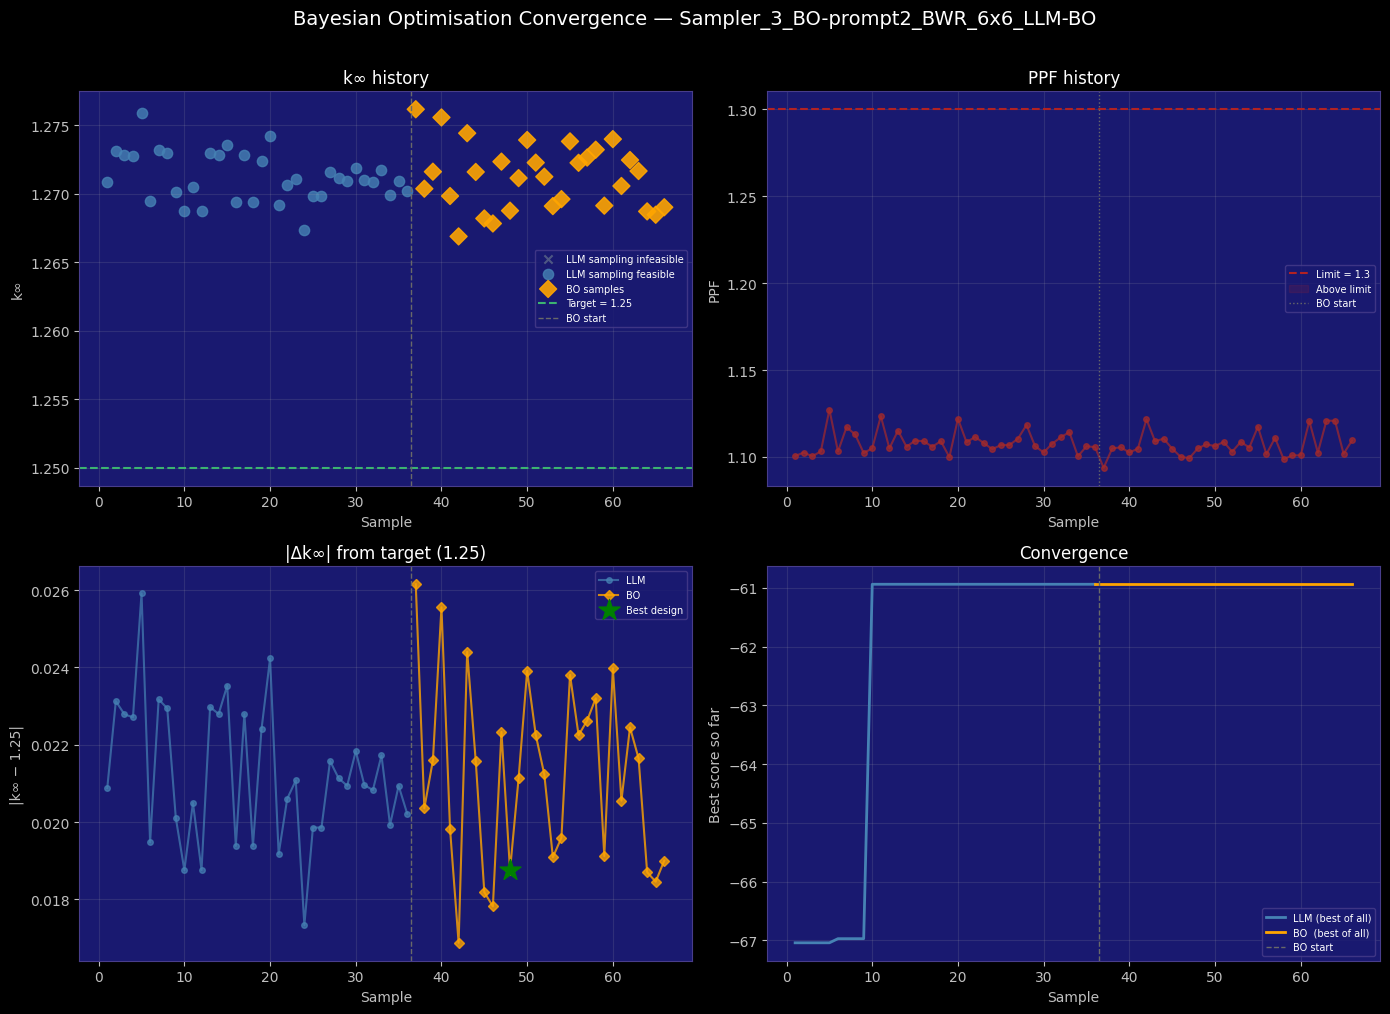

  OPTIMAL 6×6 ENRICHMENT LAYOUT (BO) — Sampler_3_BO-prompt2_BWR_6x6_LLM-BO
  Algorithm             : BO
  Assembly size         : 6×6 = 36 fuel pins
  Symmetric positions   : 21  (1/2-diagonal symmetry)
  Enrichment options    : 1.87% (Low)  /  2.53% (High)
  High-enrichment rods  : 23 / 36
  Low-enrichment rods   : 13  / 36
  Average enrichment    : 2.2917 wt%
  k∞                    : 1.26875
  k∞ target             : 1.25
  |Δk∞|                 : 0.01875  (1875.3 pcm)
  PPF                   : 1.1050  (limit ≤ 1.3)
  PPF constraint        : SATISFIED 
  Composite score       : -60.937654

  BO PARAMETERS
  LHS samples           : 36
  BO iterations         : 30
  Candidate pool        : 80000
  EI xi                 : 0.01
  GP restarts           : 10
  Random seed           : 42
  Corner masking        : True
  Adjacency penalty     : True  (weight=3.0)

  GEOMETRY & MATERIAL PARAMETERS
  Layout              : 6 × 6 = 36 fuel pins
  Pin pitch           : 1.62 cm
  Assembly side   

'../Results/Sampler_3_BO-prompt2_BWR_6x6_LLM-BO/Sampler_3_BO-prompt2_BWR_6x6_LLM-BO_report.txt'

In [15]:

fig_conv = plot_convergence(cfg_bo, bo_data, save=True)
plt.show()

export_design_report(
    cfg          = cfg_bo,
    result_data  = best,
    enr_grid_opt = enr_grid_opt,
    model_params = get_model_params(BWR_N),
    filename     = f"{MODEL_NAME}_report.txt",
    algorithm    = "BO",
)



# Validation 

In [16]:

hifi_results = f"{RESULTS_DIR}/{MODEL_NAME}_HiFi_validation.txt"


with open(hifi_results, "w") as f:
    
    
    def tee_print(*args, **kwargs):
        print(*args, **kwargs)          
        print(*args, **kwargs, file=f)  

    
    tee_print("=" * 65)
    tee_print("  VALIDATION: HIGH-FIDELITY OpenMC RUNS")
    tee_print("=" * 65)

    # Override particle counts for the HiFi re-evaluation
    cfg_bo.n_particles = 50000  # 50000+
    cfg_bo.n_inactive  = 50     
    cfg_bo.n_active    = 200

    tee_print("\nEvaluating the best layout — HiFi re-evaluation...")
    hifi_opt = evaluate_fn(best["x"])
    hifi_opt.setdefault("keff_std", 0.0)

    tee_print("All done\n")

    # Console Comparison Table
   
    algorithm = "BO"
    best_lofi = best
    sigma_lo_est = best.get("keff_std", 0.0)
    delta_keff_AB = hifi_opt["keff"] - best_lofi["keff"]

    
    var_sum = (sigma_lo_est**2 + hifi_opt["keff_std"]**2)
    z_score_ab = abs(delta_keff_AB) / np.sqrt(var_sum) if var_sum > 0 else 0.0

    tee_print("═" * 72)
    tee_print(f"  {algorithm} VALIDATION COMPARISON — Enrichment Layout Optimisation")
    tee_print("═" * 72)
    tee_print(f"{'Design':<46} {'k∞':>7} {'σ(k∞) pcm':>11} {'PPF':>8}")
    tee_print("-" * 72)
    for label, res, kstd in [
        (f"A — {algorithm} optimal layout         [LoFi]", best_lofi, sigma_lo_est),
        (f"B — {algorithm} optimal layout (re-run)[HiFi]", hifi_opt,  hifi_opt["keff_std"]),
    ]:
        kstd_str = (f"{kstd*1e5:>11.2f}"
                    if isinstance(kstd, float) and kstd > 0
                    else f"{'~'+str(round(sigma_lo_est*1e5,1)):>11}")
        tee_print(f"  {label:<44} {res['keff']:>9.5f} {kstd_str} {res['ppf']:>8.4f}")
    tee_print("═" * 72)

    tee_print(f"\n  Δk∞  (A->B): {delta_keff_AB:+.5f}  |Z| = {z_score_ab:.2f}  "
              f"{' consistent' if z_score_ab < 2 else ' check particles'}\n")


print(f" Output saved to: {hifi_results}")

  VALIDATION: HIGH-FIDELITY OpenMC RUNS

Evaluating the best layout — HiFi re-evaluation...
All done

════════════════════════════════════════════════════════════════════════
  BO VALIDATION COMPARISON — Enrichment Layout Optimisation
════════════════════════════════════════════════════════════════════════
Design                                              k∞   σ(k∞) pcm      PPF
------------------------------------------------------------------------
  A — BO optimal layout         [LoFi]           1.26875      221.43   1.1050
  B — BO optimal layout (re-run)[HiFi]           1.27111       33.19   1.0986
════════════════════════════════════════════════════════════════════════

  Δk∞  (A->B): +0.00236  |Z| = 1.05   consistent

 Output saved to: ../Results/Sampler_3_BO-prompt2_BWR_6x6_LLM-BO/Sampler_3_BO-prompt2_BWR_6x6_LLM-BO_HiFi_validation.txt
